In [1]:
import numpy as np 
import pandas as pd
from sklearn.metrics import mean_squared_error


In [4]:
df = pd.read_csv("/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/data/lendingclub_model.csv")

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/2882822895.py:1: DtypeWarning: Columns (0: hardship_loan_status) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/data/lendingclub_model.csv")


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1269458 entries, 0 to 1269457
Columns: 185 entries, loan_amnt to default
dtypes: float64(87), int64(80), str(18)
memory usage: 1.7 GB


In [6]:
drop_cols = [
    "loan_status",

    "out_prncp",
    "out_prncp_inv",

    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_prncp",
    "total_rec_int",
    "total_rec_late_fee",

    "recoveries",
    "collection_recovery_fee",

    "last_pymnt_d",
    "last_pymnt_amnt",
    "next_pymnt_d",
    "last_credit_pull_d",
    "last_fico_range_high",
    "last_fico_range_low",

    "issue_d_month",
    "issue_d_year",

    "last_pymnt_month",
    "last_pymnt_year",
    "next_pymnt_month",
    "next_pymnt_year",
    "last_credit_pull_month",
    "last_credit_pull_year",
    "emp_title",

    "title",
    "zip_code",

    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "hardship_loan_status",
    "hardship_start_month",
    "hardship_start_year",
    "hardship_end_month",
    "hardship_end_year",
    
    "payment_plan_start_month",
    "payment_plan_start_year",
    "settlement_status",
    "debt_settlement_flag_month",
    "debt_settlement_flag_year",
    "funded_amnt",
    "funded_amnt_inv",
    "fico_range_high",
]

In [7]:
# df["dti"] = df["dti"].replace(999, np.nan)
# df["dti"].describe()
df["dti"].sort_values(ascending=False).head(100)
print(df["dti"].describe(percentiles=[0.9, 0.95, 0.99]))

count    1.269458e+06
mean     1.847501e+01
std      1.129369e+01
min     -1.000000e+00
90%      2.996000e+01
95%      3.312000e+01
99%      3.855000e+01
max      9.990000e+02
Name: dti, dtype: float64


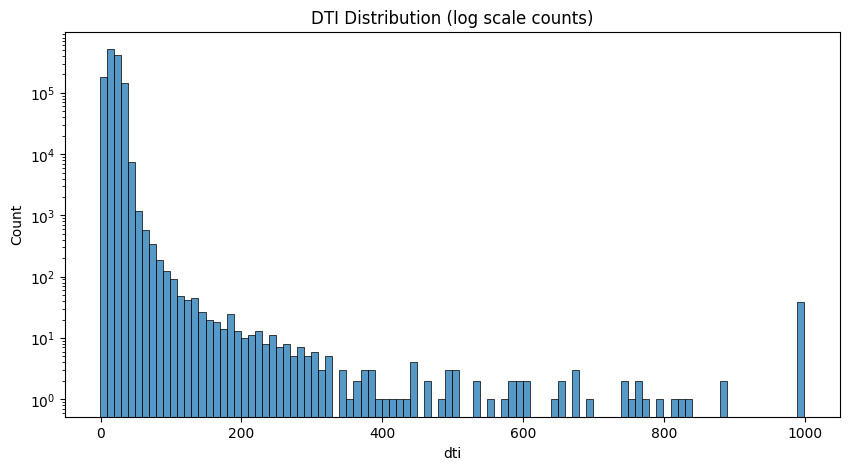

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df["dti"], bins=100)
plt.yscale("log")
plt.title("DTI Distribution (log scale counts)")
plt.show()

In [9]:
# 1. flag corrupt values (keep BEFORE overwriting)
df["dti_is_corrupt"] = (df["dti"] > 100) | (df["dti"] < 0)

# 2. replace invalid values with NaN
df.loc[df["dti"] > 100, "dti"] = np.nan
df.loc[df["dti"] < 0, "dti"] = np.nan

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/1830244924.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dti_is_corrupt"] = (df["dti"] > 100) | (df["dti"] < 0)


In [10]:
df_clean = df.drop(columns=drop_cols, errors="ignore")

In [11]:
date_cols = ["issue_d","earliest_cr_line","sec_app_earliest_cr_line"]

for col in date_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col].str.strip(), errors="coerce")
        print(f"{col}:", df[col].head())

issue_d: 0    12-2015
1    12-2015
2    12-2015
3    12-2015
4    12-2015
Name: issue_d, dtype: str
earliest_cr_line: 0    08-2003
1    12-1999
2    06-1998
3    10-1987
4    06-1990
Name: earliest_cr_line, dtype: str


/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/2418080544.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col].str.strip(), errors="coerce")
/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/2418080544.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col].str.strip(), errors="coerce")


In [12]:
start_year = df_clean["issue_d"].dt.year.min()
start_month = df_clean["issue_d"].dt.month.min()

df_clean["issue_month_num"] = (
    (df_clean["issue_d"].dt.year - start_year) * 12
    + (df_clean["issue_d"].dt.month - start_month)
)
start_year_cr = df_clean["earliest_cr_line"].dt.year.min()
start_month_cr = df_clean["earliest_cr_line"].dt.month.min()

df_clean["earliest_cr_line_month_num"] = (
    (df_clean["earliest_cr_line"].dt.year - start_year_cr) * 12
    + (df_clean["earliest_cr_line"].dt.month - start_month_cr)
)
for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] =  df[col].astype("category")



/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/326283466.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean["issue_month_num"] = (
/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/326283466.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean["earliest_cr_line_month_num"] = (
/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_19767/326283466.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. T

In [28]:
df_clean.to_csv("../data/dti_lendingclub.csv")


In [13]:
known = df_clean[df_clean["dti"].notna()].copy()
missing =  df_clean[df_clean["dti"].isna()].copy()

In [ ]:
dti_df = df_clean[df_clean["dti"].notna()].copy()
dti_df_missing = df_clean[df_clean["dti"].isna()].copy()
dti_df_missing.to_csv("../data/dti_missing_lendingclub.csv")

In [15]:
X = dti_df.drop(columns=['dti'])
X_encoded = pd.get_dummies(X,drop_first=True)

## only for after !!!!
X_missing = dti_df_missing.drop(columns=['dti'])
X_missing_encoded = pd.get_dummies(X_missing,drop_first=True)

X_encoded, X_missing_encoded = X_encoded.align(
    X_missing_encoded,
    join="left",
    axis=1,
    fill_value=0
)
X_missing= X_missing.drop(columns=["issue_d", "earliest_cr_line"])
X_missing_encoded = X_missing_encoded.drop(columns=["issue_d", "earliest_cr_line"])

y = dti_df["dti"]

In [16]:
train_end = "2016-12-01"
val_end   = "2017-12-01"

train_mask = dti_df["issue_d"] <= train_end
val_mask   = (dti_df["issue_d"] > train_end) & (dti_df["issue_d"] <= val_end)
test_mask  = dti_df["issue_d"] > val_end

X_train = X[train_mask].drop(columns=["issue_d", "earliest_cr_line"])
X_train_encoded = X_encoded[train_mask].drop(columns=["issue_d", "earliest_cr_line"])
y_train = y[train_mask]

X_val = X[val_mask].drop(columns=["issue_d", "earliest_cr_line"])
X_val_encoded = X_encoded[val_mask].drop(columns=["issue_d", "earliest_cr_line"])
y_val = y[val_mask]


X_test = X[test_mask].drop(columns=["issue_d", "earliest_cr_line"])
X_test_encoded =  X_encoded[test_mask].drop(columns=["issue_d", "earliest_cr_line"])
y_test = y[test_mask]

In [17]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 1045455 entries, 0 to 1269457
Columns: 142 entries, loan_amnt to earliest_cr_line_month_num
dtypes: bool(1), category(6), float64(71), int32(2), int64(62)
memory usage: 1.1 GB


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# X_missing_scaled = scaler.fit_transform(X_missing_encoded)

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("RMSE:", rmse(y_true, y_pred))
    print("MAE :", mean_absolute_error(y_true, y_pred))

In [17]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [18]:
ridge_pred = ridge.predict(X_val_scaled)
evaluate("Ridge", y_val, ridge_pred)


Ridge
RMSE: 7.057838959576726
MAE : 5.128011951357328


In [20]:
from lightgbm import LGBMRegressor
cat_cols = list(X.select_dtypes(include=["object","category"]).columns)


lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="huber"
)

lgbm.fit(X_train, y_train,categorical_feature=cat_cols)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8732
[LightGBM] [Info] Number of data points in the train set: 1045455, number of used features: 134
[LightGBM] [Info] Start training from score 18.390508


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'huber'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
lgbm_pred = lgbm.predict(X_val)
evaluate("LightGBM", y_val, lgbm_pred)

y_val.describe()


LightGBM
RMSE: 6.0687168583688305
MAE : 3.836976601434465


count    168082.000000
mean         18.412172
std           9.495974
min           0.000000
25%          11.720000
50%          17.660000
75%          24.320000
max         100.000000
Name: dti, dtype: float64

In [ ]:
from catboost import CatBoostRegressor

cat_cols = list(X.select_dtypes(include=["object","category"]).columns)


cat = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="Huber:delta=1.0",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200
)

cat.fit(X_train,
         y_train, 
         cat_features=cat_cols, 
         eval_set=(X_val, y_val)
         )




In [26]:
cat_pred = cat.predict(X_val)
evaluate("CatBoost", y_val, cat_pred)


CatBoost
RMSE: 4.753957697315837
MAE : 3.0394582114709325


In [22]:
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

final_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="huber"
    )
final_model.fit(X_final, y_final,categorical_feature=cat_cols)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8858
[LightGBM] [Info] Number of data points in the train set: 1213537, number of used features: 136
[LightGBM] [Info] Start training from score 18.393509


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'huber'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
preds = final_model.predict(X_test)
evaluate("lightgbm", y_test, preds)



lightgbm
RMSE: 6.9618616393557184
MAE : 4.146525557373653


In [ ]:
import joblib
import os


joblib.dump(final_model, "../models/lgbm_regression_model.pkl")
joblib.dump(X_final.columns.tolist(),"../models/regression_feature_columns.pkl")
joblib.dump(cat_cols, "../models/cat_cols_reg.pkl")

preprocess_config = {
    "drop_cols": ["issue_d", "earliest_cr_line"],
    "dti_upper_bound": 100,
    "dti_lower_bound": 0
}

joblib.dump(preprocess_config, "../models/preprocess_config.pkl")

['../models/preprocess_config.pkl']

In [27]:
import joblib

joblib.dump(X_final.columns.tolist(),"../models/regression_feature_columns.pkl")


['../models/regression_feature_columns.pkl']